## <font color=blue> 바이오 빅데이터 분석 (4)</font>

### 실습 주제: QM9 SMILES 표현 학습과 Morgan fingerprint 비교

이 노트북에서는 QM9 분자 구조 데이터에서 SMILES 문자열을 만들고, ProteinLM/ChemBERTa와 비슷한 아이디어의 작은 masked language model을 직접 학습하여 분자 embedding을 얻는다. 이후 전통적인 Morgan fingerprint와 비교한다.

### 학습 목표
1. SDF 분자 구조 파일에서 SMILES 문자열을 생성한다.
2. SMILES를 생물학/화학 언어 데이터처럼 토큰화한다.
3. masked language modeling 방식으로 작은 Transformer encoder를 학습한다.
4. 학습된 모델에서 분자 embedding을 추출한다.
5. Morgan fingerprint와 embedding을 시각화 및 물성 예측 성능으로 비교한다.

#### Machine Learning and Bioinformatics (MLBI) Lab


### 실습 절차

1. QM9 데이터 불러오기
2. SMILES 토큰화
   - QM9 SMILES를 token list로 변환합니다.
   - vocabulary와 masked language modeling 학습 corpus도 QM9 SMILES만 사용합니다.
3. Masked Language Modeling 데이터셋 만들기
   - 정답 label 없이 SMILES 일부 token을 가리고 원래 token을 맞히도록 학습 데이터를 만듭니다.
4. Tiny SMILES-BERT 학습
   - QM9 SMILES로 작은 Transformer encoder를 self-supervised pretraining합니다.
5. QM9 분자 embedding 추출
   - 이미 토큰화해둔 QM9 SMILES를 encoder에 넣고 `[CLS]` embedding을 얻습니다.
6. 기존 분자 표현 벡터 만들기
   - Morgan fingerprint와 ChemBERTa embedding도 같은 QM9 분자에 대해 계산합니다.
7. 물성 예측 성능 비교
   - Tiny SMILES-BERT embedding, Morgan fingerprint, ChemBERTa embedding을 같은 QM9 분자에서 비교합니다.
8. 가까운 분자 찾기
   - embedding 공간 또는 fingerprint 공간에서 query 분자와 가까운 분자를 찾아봅니다.
9. 모델 저장
   - QM9로 학습된 Tiny model의 weight, vocabulary, config를 저장합니다.
   - 저장된 모델은 5B에서 CTRPv2 compound SMILES embedding을 새로 계산하는 데 사용합니다.


### 0. 실습 환경

필요 패키지: `rdkit`, `torch`, `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`, `tqdm`

선택 패키지: pretrained ChemBERTa embedding을 계산하려면 `transformers`가 추가로 필요하다.

로컬 또는 Colab 환경에서 아래 셀의 설치 명령을 필요에 따라 실행한다.

In [ ]:
# 필요할 때만 실행하세요.
# conda 환경에서는 다음을 권장합니다.
# !conda install -c conda-forge rdkit pytorch tqdm -y

# pip 환경에서는 다음을 사용할 수 있습니다.
# !pip install rdkit-pypi torch tqdm

# pretrained ChemBERTa 선택 실습까지 실행하려면 아래도 설치하세요.
# !pip install transformers

In [1]:
from pathlib import Path
import importlib.util
import math
import random
import re

import numpy as np
import pandas as pd

# pandas 3.x + 일부 pyarrow 버전 조합에서 read_csv가 Arrow string 변환 중 실패할 수 있다.
pd.set_option("future.infer_string", False)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

sns.set_theme(style="whitegrid")
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

required = ["rdkit", "torch", "tqdm"]
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    raise ImportError(
        f"설치가 필요한 패키지: {missing}. 위 설치 셀을 실행한 뒤 커널을 재시작하세요."
    )

from tqdm.auto import tqdm
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem
RDLogger.DisableLog("rdApp.warning")
RDLogger.DisableLog("rdApp.error")

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

/home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cpu')

### 1. QM9 데이터 불러오기

`gdb9.sdf.csv`에는 분자별 물성값이 있고, `gdb9.sdf`에는 3D 구조와 결합 정보가 있다. SDF 파일에서 canonical SMILES를 생성한 뒤 CSV와 합친다.

전체 QM9는 13만 개 이상이므로 실습 시간에 맞춰 `MAX_MOLECULES`를 줄여 사용한다.

In [2]:
DATA_DIR = Path("gdb9")

SDF_PATH = DATA_DIR / "gdb9.sdf"
CSV_PATH = DATA_DIR / "gdb9.sdf.csv"

assert SDF_PATH.exists(), f"SDF 파일을 찾을 수 없습니다: {SDF_PATH}"
assert CSV_PATH.exists(), f"CSV 파일을 찾을 수 없습니다: {CSV_PATH}"

qm9_props = pd.read_csv(CSV_PATH)
qm9_props.head()

,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028


In [3]:
MAX_MOLECULES = 10000  # 교육 시간과 컴퓨터 성능에 맞게 2000~30000 정도로 조절

supplier = Chem.SDMolSupplier(str(SDF_PATH), removeHs=False, sanitize=True)
records = []

for mol in tqdm(supplier, total=MAX_MOLECULES):
    if mol is None:
        continue
    mol_id = mol.GetProp("_Name") if mol.HasProp("_Name") else None
    mol_no_h = Chem.RemoveHs(mol)
    smiles = Chem.MolToSmiles(mol_no_h, canonical=True)
    records.append({"mol_id": mol_id, "smiles": smiles})
    if len(records) >= MAX_MOLECULES:
        break

qm9_smiles = pd.DataFrame(records)
qm9 = qm9_smiles.merge(qm9_props, on="mol_id", how="left")
qm9 = qm9.dropna(subset=["smiles", "gap", "mu", "homo", "lumo"]).reset_index(drop=True)
qm9["source"] = "QM9"

print(qm9.shape)
qm9.head()

10095it [00:01, 7190.56it/s]                          

(10000, 21)


,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,C,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,...,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,N,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,...,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,O,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,...,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,C#C,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,...,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,C#N,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,...,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028


,mol_id,smiles,smiles_len,gap,mu
0,gdb_1,C,1,0.5048,0.0000
1,gdb_2,N,1,0.3399,1.6256
2,gdb_3,O,1,0.3615,1.8511
3,gdb_4,C#C,3,0.3351,0.0000
4,gdb_5,C#N,3,0.3796,2.8937
5,gdb_6,C=O,3,0.2263,2.1089
6,gdb_7,CC,2,0.4426,0.0000
7,gdb_8,CO,2,0.3437,1.5258
8,gdb_9,C#CC,4,0.3222,0.7156
9,gdb_10,CC#N,4,0.3640,3.8266


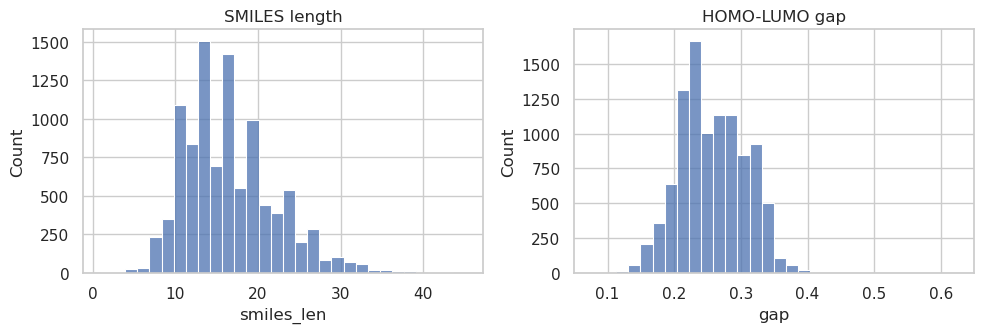

In [4]:
qm9["smiles_len"] = qm9["smiles"].str.len()
display(qm9[["mol_id", "smiles", "smiles_len", "gap", "mu"]].head(10))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.histplot(qm9["smiles_len"], bins=30, ax=axes[0])
axes[0].set_title("SMILES length")
sns.histplot(qm9["gap"], bins=30, ax=axes[1])
axes[1].set_title("HOMO-LUMO gap")
plt.tight_layout()

### 2. SMILES 토큰화

ChemBERTa류 모델은 SMILES 문자열을 화학적으로 의미 있는 단위로 나눕니다. 여기서는 bracket atom, `Cl`, `Br`, 원자 기호, 결합/분기/고리 기호를 분리하는 간단한 tokenizer를 구현합니다.

이 노트북에서는 QM9 SMILES만 사용해 vocabulary를 만들고 Tiny SMILES-BERT를 self-supervised pretraining합니다.


In [5]:
SMILES_TOKEN_PATTERN = re.compile(
    r"(\[[^\]]+\]|Br|Cl|Si|Se|Li|Na|Ca|Mg|Al|[B-IK-NO-Z][a-z]?|[bcnops]|"
    r"\%\d{2}|\d|\(|\)|\.|=|#|-|\+|\\|/|:|~|@|\?)"
)

def tokenize_smiles(smiles):
    tokens = SMILES_TOKEN_PATTERN.findall(smiles)
    if "".join(tokens) != smiles:
        raise ValueError(f"토큰화하지 못한 SMILES가 있습니다: {smiles} -> {tokens}")
    return tokens

tokenized = [tokenize_smiles(s) for s in qm9["smiles"]]
for s, toks in zip(qm9["smiles"].head(20), tokenized[:20]):
    print(f"{s:25s} -> {toks}")


C                         -> ['C']
N                         -> ['N']
O                         -> ['O']
C#C                       -> ['C', '#', 'C']
C#N                       -> ['C', '#', 'N']
C=O                       -> ['C', '=', 'O']
CC                        -> ['C', 'C']
CO                        -> ['C', 'O']
C#CC                      -> ['C', '#', 'C', 'C']
CC#N                      -> ['C', 'C', '#', 'N']
CC=O                      -> ['C', 'C', '=', 'O']
NC=O                      -> ['N', 'C', '=', 'O']
CCC                       -> ['C', 'C', 'C']
CCO                       -> ['C', 'C', 'O']
COC                       -> ['C', 'O', 'C']
C1CC1                     -> ['C', '1', 'C', 'C', '1']
C1CO1                     -> ['C', '1', 'C', 'O', '1']
CC(C)=O                   -> ['C', 'C', '(', 'C', ')', '=', 'O']
CC(N)=O                   -> ['C', 'C', '(', 'N', ')', '=', 'O']
NC(N)=O                   -> ['N', 'C', '(', 'N', ')', '=', 'O']


In [6]:
SPECIAL_TOKENS = ["[PAD]", "[CLS]", "[SEP]", "[MASK]", "[UNK]"]
vocab_tokens = SPECIAL_TOKENS + sorted({tok for toks in tokenized for tok in toks})
stoi = {tok: i for i, tok in enumerate(vocab_tokens)}
itos = {i: tok for tok, i in stoi.items()}

PAD_ID = stoi["[PAD]"]
CLS_ID = stoi["[CLS]"]
SEP_ID = stoi["[SEP]"]
MASK_ID = stoi["[MASK]"]
UNK_ID = stoi["[UNK]"]

MAX_LEN = min(80, max(len(toks) for toks in tokenized) + 2)
print("vocab size:", len(vocab_tokens))
print("max sequence length:", MAX_LEN)
np.array(vocab_tokens)


vocab size: 49
max sequence length: 25


array(['[PAD]', '[CLS]', '[SEP]', '[MASK]', '[UNK]', '#', '(', ')', '.',
       '/', '1', '2', '3', '4', '=', 'C', 'Cc', 'Cn', 'F', 'Fc', 'N',
       'Nc', 'O', 'Oc', '[C@@H]', '[C@@]', '[C@H]', '[C@]', '[CH+]',
       '[CH-]', '[CH2-]', '[CH]', '[H]', '[N@@H+]', '[N@H+]', '[NH+]',
       '[NH-]', '[NH2+]', '[NH3+]', '[O-]', '[cH+]', '[cH-]', '[n+]',
       '[nH+]', '[nH]', '\\', 'c', 'n', 'o'], dtype='<U7')

### 3. Masked Language Modeling 데이터셋

BERT 계열 모델은 일부 토큰을 `[MASK]`로 가리고 원래 토큰을 맞히도록 학습한다. 정답이 없는 SMILES 데이터만으로도 표현 학습을 수행할 수 있다는 점이 핵심이다.

In [8]:
def encode_tokens(tokens):
    ids = [CLS_ID] + [stoi.get(tok, UNK_ID) for tok in tokens[: MAX_LEN - 2]] + [SEP_ID]
    attention_mask = [1] * len(ids)
    pad_len = MAX_LEN - len(ids)
    ids = ids + [PAD_ID] * pad_len
    attention_mask = attention_mask + [0] * pad_len
    return ids, attention_mask

class SmilesMLMDataset(Dataset):
    def __init__(self, tokenized_smiles, mask_prob=0.15):
        self.tokenized_smiles = tokenized_smiles
        self.mask_prob = mask_prob

    def __len__(self):
        return len(self.tokenized_smiles)

    def __getitem__(self, idx):
        ids, attention_mask = encode_tokens(self.tokenized_smiles[idx])
        input_ids = np.array(ids, dtype=np.int64)
        labels = np.full_like(input_ids, fill_value=-100)

        for pos in range(1, int(np.sum(attention_mask)) - 1):
            if random.random() < self.mask_prob:
                labels[pos] = input_ids[pos]
                p = random.random()
                if p < 0.8:
                    input_ids[pos] = MASK_ID
                elif p < 0.9:
                    input_ids[pos] = random.randint(len(SPECIAL_TOKENS), len(vocab_tokens) - 1)

        return {
            "input_ids": torch.tensor(input_ids),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.bool),
            "labels": torch.tensor(labels),
        }

train_idx, valid_idx = train_test_split(np.arange(len(tokenized)), test_size=0.15, random_state=RANDOM_SEED)
train_tokens = [tokenized[i] for i in train_idx]
valid_tokens = [tokenized[i] for i in valid_idx]

train_loader = DataLoader(SmilesMLMDataset(train_tokens), batch_size=128, shuffle=True)
valid_loader = DataLoader(SmilesMLMDataset(valid_tokens), batch_size=256, shuffle=False)
next(iter(train_loader)).keys()


dict_keys(['input_ids', 'attention_mask', 'labels'])

### 4. 작은 ChemBERTa 스타일 Transformer Encoder

아래 모델은 교육용으로 매우 작게 만든 BERT류 encoder입니다. 실제 ChemBERTa는 대규모 SMILES corpus와 더 큰 Transformer를 사용하지만, 핵심 아이디어는 동일합니다.

이번 섹션에서는 Transformer encoder와 masked language modeling의 내부 흐름을 직접 보여주기 위해 PyTorch를 사용합니다. 4B/5B의 예측용 ANN은 TensorFlow/Keras를 사용하지만, 여기서는 `Embedding`, `TransformerEncoderLayer`, `LayerNorm`, `Linear`처럼 Transformer 구성요소가 코드에 명확히 드러나는 PyTorch 구현이 설명에 더 적합합니다.


In [9]:
class TinySmilesBERT(nn.Module):
    def __init__(self, vocab_size, max_len, dim=96, n_heads=4, n_layers=3, dropout=0.1):
        # PyTorch module을 상속받는 신경망 클래스를 초기화합니다.
        super().__init__()

        # token id를 dense vector로 바꾸는 embedding layer입니다.
        # 예: "C", "O", "=" 같은 SMILES token이 dim차원 벡터가 됩니다.
        self.token_embedding = nn.Embedding(vocab_size, dim, padding_idx=PAD_ID)

        # Transformer는 순서 정보를 직접 알지 못하므로 position embedding을 더해줍니다.
        self.position_embedding = nn.Embedding(max_len, dim)

        # Transformer encoder block 하나를 정의합니다.
        # self-attention + feed-forward network + normalization/dropout이 들어 있습니다.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,              # token embedding 차원
            nhead=n_heads,            # multi-head attention head 수
            dim_feedforward=dim * 4,  # attention 뒤 feed-forward layer 크기
            dropout=dropout,
            batch_first=True,         # input shape을 (batch, seq, feature)로 사용
            activation="gelu",        # BERT 계열에서 자주 쓰는 activation
        )

        # encoder block을 n_layers개 쌓아 작은 Transformer encoder를 만듭니다.
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # encoder 출력의 scale을 안정화하는 layer normalization입니다.
        self.norm = nn.LayerNorm(dim)

        # masked token의 원래 token id를 맞히기 위한 classification head입니다.
        self.mlm_head = nn.Linear(dim, vocab_size)

    def forward(self, input_ids, attention_mask):
        # input_ids shape: (batch_size, sequence_length)
        batch_size, seq_len = input_ids.shape

        # 각 token 위치에 해당하는 position id를 만듭니다.
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)

        # token embedding과 position embedding을 더해 Transformer 입력을 만듭니다.
        x = self.token_embedding(input_ids) + self.position_embedding(positions)

        # attention_mask는 True가 실제 token, False가 padding입니다.
        # PyTorch Transformer의 src_key_padding_mask는 True가 무시할 위치라서 반대로 바꿉니다.
        key_padding_mask = ~attention_mask

        # self-attention을 통해 SMILES token들 사이의 문맥 정보를 학습합니다.
        hidden = self.encoder(x, src_key_padding_mask=key_padding_mask)

        # hidden representation을 정규화합니다.
        hidden = self.norm(hidden)

        # 각 위치에서 vocabulary token 중 무엇인지 예측하는 logit을 계산합니다.
        logits = self.mlm_head(hidden)

        # logits는 masked language modeling loss에 사용하고,
        # hidden은 나중에 [CLS] embedding 추출에 사용합니다.
        return logits, hidden


# vocab 크기와 최대 sequence 길이에 맞춰 Tiny SMILES-BERT 모델을 생성합니다.
model = TinySmilesBERT(len(vocab_tokens), MAX_LEN).to(device)

# AdamW는 Transformer/BERT 계열 학습에서 자주 쓰는 optimizer입니다.
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-2)

# masking하지 않은 위치는 label=-100으로 두었으므로 loss 계산에서 무시합니다.
criterion = nn.CrossEntropyLoss(ignore_index=-100)

# 전체 trainable parameter 수를 확인합니다.
sum(p.numel() for p in model.parameters())


347569

In [10]:
def run_epoch(loader, train=True):
    # train=True이면 학습 모드, False이면 평가 모드로 전환합니다.
    model.train(train)
    total_loss = 0.0
    total_batches = 0

    for batch in tqdm(loader, leave=False):
        # batch data를 CPU/GPU device로 옮깁니다.
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # train=False일 때는 gradient 계산을 끄므로 더 빠르고 메모리를 덜 씁니다.
        with torch.set_grad_enabled(train):
            # Transformer가 각 token 위치의 vocabulary logit을 예측합니다.
            logits, _ = model(input_ids, attention_mask)

            # CrossEntropyLoss는 (sample, class) 형태를 기대하므로 token 차원을 펼칩니다.
            loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))

            if train:
                # 이전 batch에서 계산된 gradient를 초기화합니다.
                optimizer.zero_grad()
                # loss를 기준으로 모든 parameter의 gradient를 계산합니다.
                loss.backward()
                # gradient가 너무 커지는 것을 막아 학습을 안정화합니다.
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                # optimizer가 parameter를 한 step 업데이트합니다.
                optimizer.step()

        # batch loss를 누적해 epoch 평균 loss를 계산합니다.
        total_loss += loss.item()
        total_batches += 1

    return total_loss / max(total_batches, 1)


EPOCHS = 5
history = []
for epoch in range(1, EPOCHS + 1):
    # training set으로 모델 weight를 업데이트합니다.
    train_loss = run_epoch(train_loader, train=True)
    # validation set으로 현재 모델의 일반화 loss를 확인합니다.
    valid_loss = run_epoch(valid_loader, train=False)
    history.append({"epoch": epoch, "train_loss": train_loss, "valid_loss": valid_loss})
    print(f"epoch {epoch:02d} | train loss {train_loss:.4f} | valid loss {valid_loss:.4f}")

pd.DataFrame(history)


  0%|          | 0/6 [00:00<?, ?it/s]          /home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/site-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1739474892959/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


epoch 01 | train loss 2.7730 | valid loss 2.2941


epoch 02 | train loss 2.1583 | valid loss 1.9869


epoch 03 | train loss 1.8805 | valid loss 1.7290


epoch 04 | train loss 1.7032 | valid loss 1.6027


epoch 05 | train loss 1.5823 | valid loss 1.4778


,epoch,train_loss,valid_loss
0,1,2.773025,2.294104
1,2,2.158316,1.986898
2,3,1.880514,1.728962
3,4,1.703192,1.602717
4,5,1.582341,1.477844


### 5. 분자 embedding 추출

Transformer 출력에서 `[CLS]` 위치 벡터를 분자 전체 embedding으로 사용합니다. 평균 pooling도 가능하지만, 여기서는 BERT 계열 관례에 맞춰 `[CLS]` embedding을 사용합니다.

섹션 2에서 이미 QM9 SMILES를 토큰화해 둔 `tokenized`를 재사용합니다.


In [11]:
class SmilesInferenceDataset(Dataset):
    def __init__(self, tokenized_smiles):
        self.tokenized_smiles = tokenized_smiles

    def __len__(self):
        return len(self.tokenized_smiles)

    def __getitem__(self, idx):
        ids, attention_mask = encode_tokens(self.tokenized_smiles[idx])
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.bool),
        }

# 섹션 2에서 이미 계산한 QM9 SMILES tokenized 결과를 재사용합니다.
infer_loader = DataLoader(SmilesInferenceDataset(tokenized), batch_size=256, shuffle=False)

model.eval()
embeddings = []
with torch.no_grad():
    for batch in tqdm(infer_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        _, hidden = model(input_ids, attention_mask)
        cls_embedding = hidden[:, 0, :].cpu().numpy()
        embeddings.append(cls_embedding)

X_bert = np.vstack(embeddings)
X_bert.shape

100%|██████████| 40/40 [00:34<00:00,  1.17it/s]


(10000, 96)

### 6. 기존 분자 표현 벡터 만들기 (비교용)

이 섹션에서는 같은 SMILES로부터 두 가지 compound representation을 만듭니다. 첫 번째는 rule-based Morgan fingerprint이고, 두 번째는 pretrained ChemBERTa embedding입니다.


#### 6-1. Morgan fingerprint 계산

Morgan fingerprint는 분자의 원자 주변 부분구조를 bit vector로 표현한다. 학습이 필요 없고 해석이 비교적 쉬워서 전통적인 화합물 표현으로 널리 사용된다.

In [12]:
def morgan_fingerprint_from_smiles(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

X_morgan = np.vstack([morgan_fingerprint_from_smiles(s) for s in tqdm(qm9["smiles"])])
X_morgan.shape

100%|██████████| 10000/10000 [00:00<00:00, 10122.91it/s]


(10000, 2048)

In [13]:
X_morgan.shape

(10000, 2048)

In [14]:
X_morgan[:3,:]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

#### 6-2. Pretrained ChemBERTa embedding 계산

아래 셀은 선택 실습이다. Hugging Face에 공개된 pretrained ChemBERTa 계열 모델을 불러와 SMILES embedding을 계산한다. 처음 실행할 때는 모델 다운로드가 필요하며, 인터넷 연결 또는 로컬 캐시가 필요하다.

실행에 성공하면 `X_chemberta`가 생성되고, 이후 PCA 시각화와 물성 예측 비교에 자동으로 포함된다.

In [31]:
!pip install transformers

  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 67.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 55.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 78.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 74.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 47.9 MB/s  0:00:00
Using cached rich-15.0.0-py3-none-any.whl (310 kB)
Using cached markdown_it_py-4.2.0-py3-none-any.whl (91 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [transformers] [transformers]ub]


In [15]:
CHEMBERTA_MODEL_NAME = "DeepChem/ChemBERTa-77M-MLM"
CHEMBERTA_BATCH_SIZE = 128

try:
    from transformers import AutoModel, AutoTokenizer

    chemberta_tokenizer = AutoTokenizer.from_pretrained(CHEMBERTA_MODEL_NAME)
    chemberta_model = AutoModel.from_pretrained(CHEMBERTA_MODEL_NAME).to(device)
    chemberta_model.eval()

    chemberta_embeddings = []
    smiles_list = qm9["smiles"].tolist()

    with torch.no_grad():
        for start in tqdm(range(0, len(smiles_list), CHEMBERTA_BATCH_SIZE)):
            batch_smiles = smiles_list[start : start + CHEMBERTA_BATCH_SIZE]
            encoded = chemberta_tokenizer(
                batch_smiles,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors="pt",
            )
            encoded = {k: v.to(device) for k, v in encoded.items()}
            output = chemberta_model(**encoded)
            cls_embedding = output.last_hidden_state[:, 0, :].cpu().numpy()
            chemberta_embeddings.append(cls_embedding)

    X_chemberta = np.vstack(chemberta_embeddings).astype(np.float32)
    print("ChemBERTa embedding shape:", X_chemberta.shape)

except Exception as e:
    X_chemberta = None
    print("ChemBERTa embedding을 건너뜁니다.")
    print("이 셀을 실행하려면 transformers 설치와 pretrained model 다운로드/캐시가 필요합니다.")
    print(type(e).__name__, e)

Loading weights: 100%|██████████| 53/53 [00:00<00:00, 12285.74it/s]
[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MLM
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.decoder.bias      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 79/79 [01:08<00:00,  1.16it/s]

ChemBERTa embedding shape: (10000, 384)


### 7. 물성 예측으로 비교

같은 회귀 모델을 사용해 두 표현의 예측 성능을 비교한다. 여기서는 빠르고 안정적인 Ridge regression을 사용한다.

주의: 이 실습의 Tiny 모델은 매우 작은 데이터와 짧은 학습으로 만든 것이므로, Morgan fingerprint보다 항상 좋아야 하는 것은 아니다. 핵심은 자기지도 표현학습의 개념과 비교 방법을 이해하는 것이다.

In [16]:
def evaluate_representation(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED
    )
    reg = make_pipeline(StandardScaler(with_mean=True), Ridge(alpha=1.0))
    reg.fit(X_train, y_train)
    pred = reg.predict(X_test)
    return {
        "representation": name,
        "r2": r2_score(y_test, pred),
        "mae": mean_absolute_error(y_test, pred),
    }

representations = {
    "Tiny SMILES-BERT": X_bert,
    "Morgan fingerprint": X_morgan,
}
if globals().get("X_chemberta") is not None:
    representations["Pretrained ChemBERTa"] = X_chemberta

targets = ["gap", "mu", "homo", "lumo"]
results = []
for target in targets:
    y = qm9[target].to_numpy(dtype=np.float32)
    for name, X in representations.items():
        result = evaluate_representation(X, y, name)
        result["target"] = target
        results.append(result)

result_df = pd.DataFrame(results)
result_df

,representation,r2,mae,target
0,Tiny SMILES-BERT,0.710568,0.021141,gap
1,Morgan fingerprint,0.841641,0.015097,gap
2,Pretrained ChemBERTa,0.782542,0.018139,gap
3,Tiny SMILES-BERT,0.331808,0.956944,mu
4,Morgan fingerprint,0.451860,0.914418,mu
5,Pretrained ChemBERTa,0.438435,0.857715,mu
6,Tiny SMILES-BERT,0.554337,0.013446,homo
7,Morgan fingerprint,0.745356,0.010155,homo
8,Pretrained ChemBERTa,0.685026,0.011464,homo
9,Tiny SMILES-BERT,0.734919,0.019741,lumo


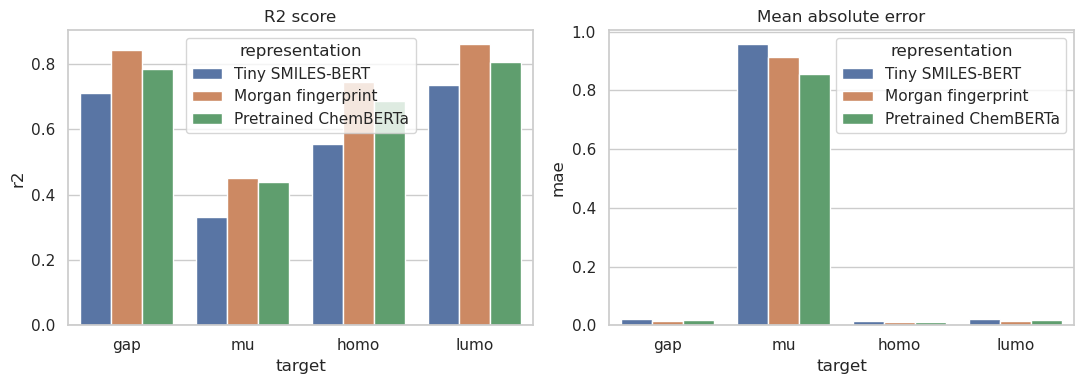

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=result_df, x="target", y="r2", hue="representation", ax=axes[0])
axes[0].set_title("R2 score")
axes[0].axhline(0, color="black", linewidth=0.8)

sns.barplot(data=result_df, x="target", y="mae", hue="representation", ax=axes[1])
axes[1].set_title("Mean absolute error")
plt.tight_layout()

### 8. 가까운 분자 찾기

Embedding 공간에서 cosine similarity가 높은 분자를 찾아 본다. Morgan fingerprint의 Tanimoto similarity와 비교해도 좋다.

In [18]:
def nearest_by_cosine(X, query_index, top_k=8):
    sims = cosine_similarity(X[query_index: query_index + 1], X).ravel()
    order = np.argsort(-sims)
    order = [i for i in order if i != query_index][:top_k]
    out = qm9.iloc[order][["mol_id", "smiles", "gap", "mu"]].copy()
    out.insert(0, "similarity", sims[order])
    return out

query_index = 100
print("query molecule")
display(qm9.iloc[[query_index]][["mol_id", "smiles", "gap", "mu"]])

print("nearest neighbors by Tiny SMILES-BERT embedding")
display(nearest_by_cosine(X_bert, query_index))

print("nearest neighbors by Morgan fingerprint vector")
display(nearest_by_cosine(X_morgan, query_index))

query molecule


,mol_id,smiles,gap,mu
100,gdb_101,C[C@H]1C[C@H]1O,0.334,1.3092


nearest neighbors by Tiny SMILES-BERT embedding


,similarity,mol_id,smiles,gap,mu
430,0.994936,gdb_433,C[C@H]1CC[C@H]1O,0.3274,1.3078
611,0.992056,gdb_614,C[C@H]1C[C@H]1CO,0.3366,1.3825
617,0.990977,gdb_620,CC[C@H]1O[C@H]1C,0.3538,1.7551
95,0.990663,gdb_96,C[C@H]1CCO1,0.3325,1.6826
615,0.989496,gdb_618,CC[C@H]1C[C@H]1O,0.3338,1.2983
620,0.986956,gdb_623,CO[C@H]1C[C@H]1C,0.3346,0.9946
619,0.986135,gdb_622,C[N@H+]1C[C@H]1CO,0.2927,2.1379
148,0.986028,gdb_150,CC[C@H]1CO1,0.3599,1.7468


nearest neighbors by Morgan fingerprint vector


,similarity,mol_id,smiles,gap,mu
7940,0.816497,gdb_8006,C[C@H]1C[C@@H](C)[C@@H](O)C1,0.3268,1.3484
7944,0.816497,gdb_8010,C[C@H]1C[C@@H](O)C[C@H]1O,0.3094,2.5068
2191,0.760639,gdb_2207,C[C@H]1C[C@@H](O)[C@H]1O,0.3031,1.1573
2190,0.760639,gdb_2206,C[C@@H]1[C@H](O)C[C@@H]1C,0.3251,1.3159
7943,0.730297,gdb_8009,C[C@@H]1C[C@H](O)C[C@@H]1C,0.3298,1.4153
430,0.730297,gdb_433,C[C@H]1CC[C@H]1O,0.3274,1.3078
7942,0.730297,gdb_8008,C[C@H]1C[C@@H](O)[C@@H](O)C1,0.3168,0.7890
2189,0.730297,gdb_2205,C[C@@H]1C[C@H](C)[C@@H]1O,0.3103,1.4024


### 9. 결과 저장

5B에서 새로운 CTRPv2 compound의 embedding을 계산하려면 이미 계산된 QM9 embedding matrix가 아니라 Tiny SMILES-BERT의 model weight, vocabulary, config가 필요합니다.

아래에서는 참고용 QM9 SMILES subset CSV와, QM9로 self-supervised pretraining된 Tiny SMILES-BERT 모델 파일을 저장합니다.


In [20]:
OUT_DIR = Path("Work_BioBigdata_KOTHEA/outputs")
if not OUT_DIR.parent.exists():
    OUT_DIR = Path("embedding_outputs")
OUT_DIR.mkdir(exist_ok=True)

qm9[["mol_id", "smiles", "gap", "mu", "homo", "lumo"]].to_csv(OUT_DIR / "qm9_smiles_subset.csv", index=False)

print("QM9 subset saved to", (OUT_DIR / "qm9_smiles_subset.csv").resolve())


saved to /mnt/HDD2/Google_drive/Work_BioBigdata_KOTHEA/embedding_outputs


### 선택 실습: Tiny SMILES-BERT 모델 저장

아래 셀은 5B 또는 다른 후속 실습에서 같은 Tiny SMILES-BERT encoder를 다시 불러올 수 있도록 model weight, vocabulary, config를 저장합니다.

저장된 파일을 사용하면 QM9에 없던 새로운 SMILES 데이터도 같은 tokenizer와 encoder에 통과시켜 embedding을 새로 계산할 수 있습니다.


In [ ]:
import json

TINY_MODEL_DIR = OUT_DIR / "tiny_smiles_bert_model"
TINY_MODEL_DIR.mkdir(exist_ok=True)

# 모델 구조를 다시 만들 때 필요한 설정값을 저장합니다.
tiny_config = {
    "vocab_size": len(vocab_tokens),
    "max_len": MAX_LEN,
    "dim": 96,
    "n_heads": 4,
    "n_layers": 3,
    "dropout": 0.1,
    "pad_token": "[PAD]",
    "cls_token": "[CLS]",
    "sep_token": "[SEP]",
    "mask_token": "[MASK]",
    "unk_token": "[UNK]",
}

# PyTorch 모델 weight를 저장합니다.
torch.save(model.state_dict(), TINY_MODEL_DIR / "tiny_smiles_bert_state_dict.pt")

# tokenizer vocabulary와 token-id mapping을 저장합니다.
with open(TINY_MODEL_DIR / "tiny_smiles_bert_vocab.json", "w", encoding="utf-8") as f:
    json.dump({"vocab_tokens": vocab_tokens, "stoi": stoi}, f, ensure_ascii=False, indent=2)

# 모델 config를 저장합니다.
with open(TINY_MODEL_DIR / "tiny_smiles_bert_config.json", "w", encoding="utf-8") as f:
    json.dump(tiny_config, f, ensure_ascii=False, indent=2)

print("Tiny SMILES-BERT model files saved to", TINY_MODEL_DIR.resolve())

### 토의 질문

1. Morgan fingerprint와 학습 기반 embedding은 각각 어떤 장단점이 있는가?
2. Tiny SMILES-BERT의 성능을 높이려면 데이터 수, 모델 크기, 학습 epoch, tokenizer 중 무엇을 바꿀 수 있을까?
3. SMILES는 같은 분자라도 여러 문자열로 표현될 수 있다. randomized SMILES augmentation을 쓰면 어떤 효과가 있을까?
4. ProteinLM의 아미노산 서열 표현학습과 SMILES 표현학습은 어떤 점이 닮았고 어떤 점이 다른가?
